In [9]:
print("Municipal Data Analysis – Python działa!")

Municipal Data Analysis – Python działa!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Municipal Data Analysis – Baden-Württemberg

## Demographic and structural analysis of municipalities

This project explores municipal-level data from Baden-Württemberg using Python, pandas, SQL and data visualization.

**Data source:** Statistisches Landesamt Baden-Württemberg

### Objectives
- explore municipal and demographic data
- compare municipalities and regional indicators
- identify demographic patterns
- create clear visualizations for public-sector decision making

In [11]:
df = pd.read_csv(
    "data/raw/11111-0001_flat.csv",
    sep=";",
    encoding="latin1"
)

In [12]:
df = pd.read_csv(
    "data/raw/11111-0001_flat.csv",
    sep=";",
    encoding="latin1"
)

In [13]:
df.head()

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,11111,Feststellung des Gebietsstands,STAG,Stichtag,2023-12-31,REGI,Regionen,0841REGI,Region Neckar-Alb,2464543381,m²,FLC006,Gebietsfläche
1,11111,Feststellung des Gebietsstands,STAG,Stichtag,2023-12-31,REGI,Regionen,0841REGI,Region Neckar-Alb,292,EW/km²,FLC106,Bevölkerungsdichte
2,11111,Feststellung des Gebietsstands,STAG,Stichtag,2023-12-31,REGI,Regionen,0813REGI,Region Ostwürttemberg,2138525404,m²,FLC006,Gebietsfläche
3,11111,Feststellung des Gebietsstands,STAG,Stichtag,2023-12-31,REGI,Regionen,0813REGI,Region Ostwürttemberg,212,EW/km²,FLC106,Bevölkerungsdichte
4,11111,Feststellung des Gebietsstands,STAG,Stichtag,2023-12-31,REGI,Regionen,0831REGI,Region Südlicher Oberrhein,4061509953,m²,FLC006,Gebietsfläche


In [14]:
df.shape

(10458, 13)

In [15]:
df.columns.tolist()

['statistics_code',
 'statistics_label',
 'time_code',
 'time_label',
 'time',
 '1_variable_code',
 '1_variable_label',
 '1_variable_attribute_code',
 '1_variable_attribute_label',
 'value',
 'value_unit',
 'value_variable_code',
 'value_variable_label']

In [16]:
df["value_variable_label"].value_counts()

value_variable_label
Gebietsfläche         3486
Bevölkerungsdichte    3486
Bevölkerungsstand     3486
Name: count, dtype: int64

In [17]:
df["time"].value_counts().sort_index()

time
2022-12-31    3486
2023-12-31    3486
2024-12-31    3486
Name: count, dtype: int64

In [18]:
df["1_variable_attribute_label"].head(20)

0                Region Neckar-Alb
1                Region Neckar-Alb
2            Region Ostwürttemberg
3            Region Ostwürttemberg
4       Region Südlicher Oberrhein
5       Region Südlicher Oberrhein
6                 Region Stuttgart
7                 Region Stuttgart
8     Region Bodensee-Oberschwaben
9     Region Bodensee-Oberschwaben
10                Region Karlsruhe
11                Region Karlsruhe
12          Region Nordschwarzwald
13          Region Nordschwarzwald
14              Region Donau-Iller
15              Region Donau-Iller
16           Region Ostwürttemberg
17           Region Ostwürttemberg
18       Region Hochrhein-Bodensee
19       Region Hochrhein-Bodensee
Name: 1_variable_attribute_label, dtype: object

In [19]:
df[[
    "1_variable_attribute_code",
    "1_variable_attribute_label"
]].head(30)

,1_variable_attribute_code,1_variable_attribute_label
0,0841REGI,Region Neckar-Alb
1,0841REGI,Region Neckar-Alb
2,0813REGI,Region Ostwürttemberg
3,0813REGI,Region Ostwürttemberg
4,0831REGI,Region Südlicher Oberrhein
5,0831REGI,Region Südlicher Oberrhein
6,0811REGI,Region Stuttgart
7,0811REGI,Region Stuttgart
8,0843REGI,Region Bodensee-Oberschwaben
9,0843REGI,Region Bodensee-Oberschwaben


In [20]:
df["1_variable_attribute_code"].str[-4:].value_counts()

1_variable_attribute_code
GEMI    9909
KRSI     396
REGI     108
GBZI      36
08LA       9
Name: count, dtype: int64

In [21]:
df[
    (df["1_variable_attribute_code"].str.endswith("GEMI")) &
    (df["1_variable_attribute_label"].str.contains("Dietenheim|Ulm", case=False, na=False))
][["1_variable_attribute_code", "1_variable_attribute_label"]].drop_duplicates()

,1_variable_attribute_code,1_variable_attribute_label
556,08125110GEMI,Obersulm
752,08421000GEMI,"Ulm, Universitätsstadt"
1848,08425028GEMI,"Dietenheim, Stadt"
2282,08125065GEMI,"Neckarsulm, Stadt"


In [22]:
gemeinden = df[df["1_variable_attribute_code"].str.endswith("GEMI")].copy()

gemeinden.shape

(9909, 13)

In [23]:
gemeinden["1_variable_attribute_code"].nunique()

1101

In [24]:
gemeinden[
    gemeinden["1_variable_attribute_label"] == "Dietenheim, Stadt"
][[
    "time",
    "value_variable_label",
    "value",
    "value_unit"
]]

,time,value_variable_label,value,value_unit
1848,2023-12-31,Bevölkerungsdichte,364,EW/km²
1849,2023-12-31,Gebietsfläche,18752964,m²
2558,2024-12-31,Bevölkerungsdichte,365,EW/km²
2559,2024-12-31,Gebietsfläche,18752959,m²
4210,2022-12-31,Bevölkerungsdichte,369,EW/km²
4211,2022-12-31,Gebietsfläche,18753092,m²
7821,2023-12-31,Bevölkerungsstand,6832,Anzahl
8176,2024-12-31,Bevölkerungsstand,6843,Anzahl
9002,2022-12-31,Bevölkerungsstand,6914,Anzahl


In [25]:
analysis = gemeinden.pivot_table(
    index=[
        "1_variable_attribute_code",
        "1_variable_attribute_label",
        "time"
    ],
    columns="value_variable_label",
    values="value",
    aggfunc="first"
).reset_index()

analysis.head()

value_variable_label,1_variable_attribute_code,1_variable_attribute_label,time,Bevölkerungsdichte,Bevölkerungsstand,Gebietsfläche
0,08111000GEMI,"Stuttgart, Landeshauptstadt",2022-12-31,2952,612041,207332201
1,08111000GEMI,"Stuttgart, Landeshauptstadt",2023-12-31,2957,613111,207332184
2,08111000GEMI,"Stuttgart, Landeshauptstadt",2024-12-31,2955,612663,207332247
3,08115001GEMI,Aidlingen,2022-12-31,346,9201,26559282
4,08115001GEMI,Aidlingen,2023-12-31,350,9288,26559287


In [26]:
analysis.shape

(3303, 6)

In [27]:
analysis = analysis.rename(columns={
    "1_variable_attribute_code": "municipality_code",
    "1_variable_attribute_label": "municipality",
    "time": "date",
    "Bevölkerungsdichte": "population_density",
    "Bevölkerungsstand": "population",
    "Gebietsfläche": "area_m2"
})

analysis.head()

value_variable_label,municipality_code,municipality,date,population_density,population,area_m2
0,08111000GEMI,"Stuttgart, Landeshauptstadt",2022-12-31,2952,612041,207332201
1,08111000GEMI,"Stuttgart, Landeshauptstadt",2023-12-31,2957,613111,207332184
2,08111000GEMI,"Stuttgart, Landeshauptstadt",2024-12-31,2955,612663,207332247
3,08115001GEMI,Aidlingen,2022-12-31,346,9201,26559282
4,08115001GEMI,Aidlingen,2023-12-31,350,9288,26559287


In [28]:
analysis.columns.name = None

analysis.head()

,municipality_code,municipality,date,population_density,population,area_m2
0,08111000GEMI,"Stuttgart, Landeshauptstadt",2022-12-31,2952,612041,207332201
1,08111000GEMI,"Stuttgart, Landeshauptstadt",2023-12-31,2957,613111,207332184
2,08111000GEMI,"Stuttgart, Landeshauptstadt",2024-12-31,2955,612663,207332247
3,08115001GEMI,Aidlingen,2022-12-31,346,9201,26559282
4,08115001GEMI,Aidlingen,2023-12-31,350,9288,26559287


In [29]:
analysis.isna().sum()

municipality_code     0
municipality          0
date                  0
population_density    0
population            0
area_m2               0
dtype: int64

In [30]:
analysis.duplicated(
    subset=["municipality_code", "date"]
).sum()

np.int64(0)

In [31]:
analysis["population"].describe()

count      3303.000000
mean      10186.000303
std       27179.715895
min          92.000000
25%        2561.500000
50%        4859.000000
75%        9555.000000
max      613111.000000
Name: population, dtype: float64

In [32]:
latest = analysis[analysis["date"] == "2024-12-31"].copy()

latest.shape

(1101, 6)

In [33]:
latest["area_km2"] = latest["area_m2"] / 1_000_000

top_population = (
    latest
    .nlargest(10, "population")
    [["municipality", "population", "population_density", "area_km2"]]
)

top_population

,municipality,population,population_density,area_km2
2,"Stuttgart, Landeshauptstadt",612663,2955,207.332247
1205,"Mannheim, Universitätsstadt",318035,2194,144.972038
1034,"Karlsruhe, Stadt",309050,1782,173.424053
1661,"Freiburg im Breisgau, Stadt",237460,1552,153.039723
1202,"Heidelberg, Stadt",155756,1431,108.831317
1451,"Pforzheim, Stadt",134912,1377,97.986300
539,"Heilbronn, Universitätsstadt",131986,1321,99.890978
2741,"Ulm, Universitätsstadt",129882,1094,118.680133
2582,"Reutlingen, Stadt",118852,1365,87.041190
116,"Esslingen am Neckar, Stadt",96182,2072,46.426368


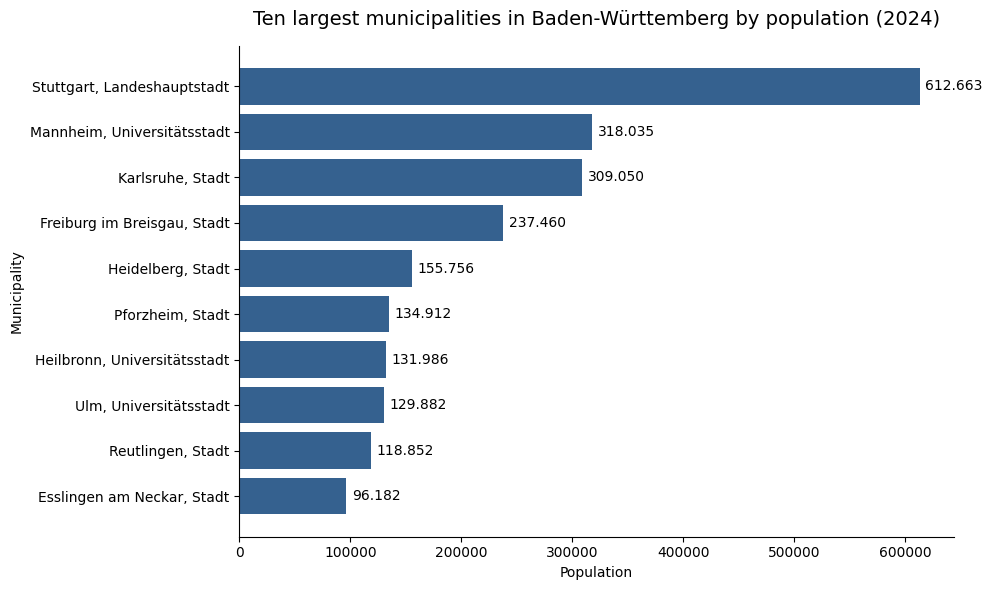

In [34]:
plot_data = top_population.sort_values("population")

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data["municipality"],
    plot_data["population"],
    color="#35618f"
)

ax.set_title(
    "Ten largest municipalities in Baden-Württemberg by population (2024)",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Population")
ax.set_ylabel("Municipality")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    value = int(bar.get_width())
    label = f"{value:,}".replace(",", ".")
    ax.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "visuals/top_10_municipalities_population_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
first_date = analysis["date"].min()
last_date = analysis["date"].max()

population_change = (
    analysis
    .pivot(
        index=["municipality_code", "municipality"],
        columns="date",
        values="population"
    )
    .reset_index()
)

population_change["population_change"] = (
    population_change[last_date] - population_change[first_date]
)

population_change["population_change_pct"] = (
    population_change["population_change"]
    / population_change[first_date]
    * 100
)

population_change.nlargest(
    10,
    "population_change_pct"
)[
    [
        "municipality",
        first_date,
        last_date,
        "population_change",
        "population_change_pct"
    ]
]

date,municipality,2022-12-31,2024-12-31,population_change,population_change_pct
959,Unterstadion,797,909,112,14.052698
745,Renquishausen,760,826,66,8.684211
197,Jagsthausen,1618,1747,129,7.972806
591,Schallstadt,6481,6937,456,7.035951
715,Tuningen,3079,3292,213,6.917830
929,Emeringen,165,176,11,6.666667
438,Gaiberg,2326,2480,154,6.620808
663,Ringsheim,2492,2645,153,6.139647
982,Dürnau,459,487,28,6.100218
146,"Korntal-Münchingen, Stadt",18641,19654,1013,5.434258


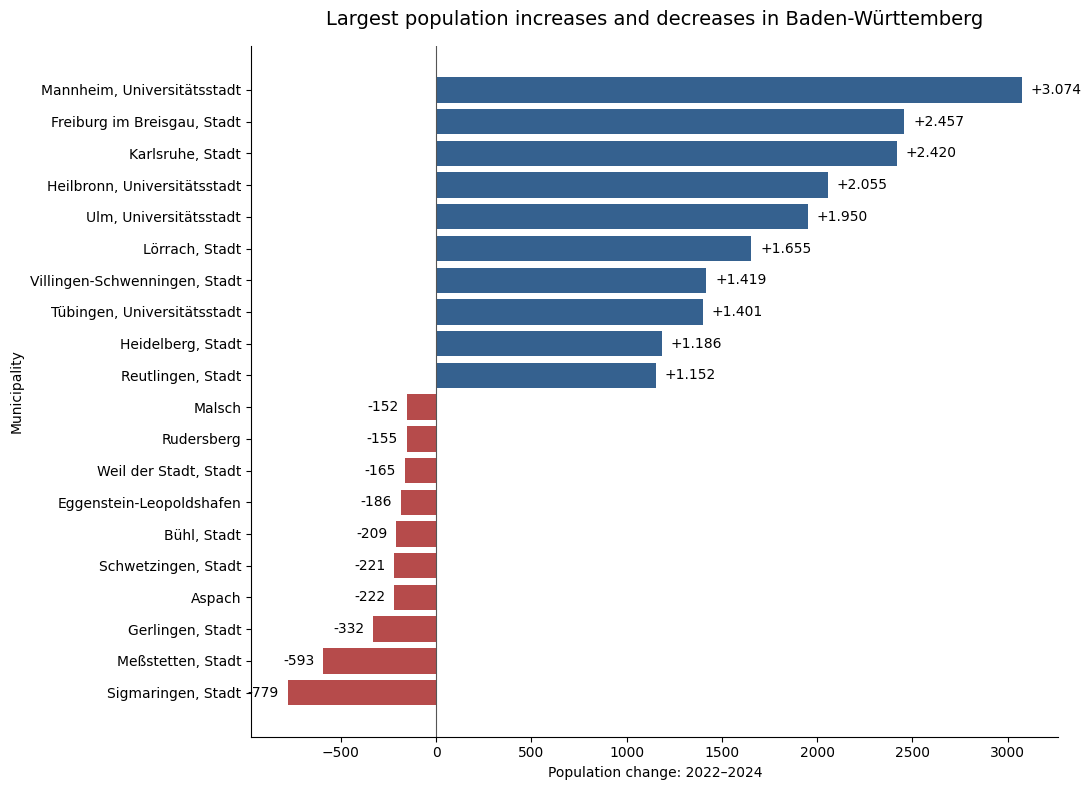

In [36]:
largest_growth = population_change.nlargest(
    10, "population_change"
)

largest_decline = population_change.nsmallest(
    10, "population_change"
)

change_chart = pd.concat(
    [largest_growth, largest_decline]
).sort_values("population_change")

colors = [
    "#b64b4b" if value < 0 else "#35618f"
    for value in change_chart["population_change"]
]

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    change_chart["municipality"],
    change_chart["population_change"],
    color=colors
)

ax.axvline(0, color="#555555", linewidth=0.8)

ax.set_title(
    "Largest population increases and decreases in Baden-Württemberg",
    fontsize=14,
    pad=15
)
ax.set_xlabel(
    f"Population change: {str(first_date)[:4]}–{str(last_date)[:4]}"
)
ax.set_ylabel("Municipality")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

offset = change_chart["population_change"].abs().max() * 0.015

for bar, value in zip(bars, change_chart["population_change"]):
    x_position = value + offset if value >= 0 else value - offset
    alignment = "left" if value >= 0 else "right"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):+,.0f}".replace(",", "."),
        va="center",
        ha=alignment
    )

plt.tight_layout()

plt.savefig(
    "visuals/largest_population_changes_2022_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

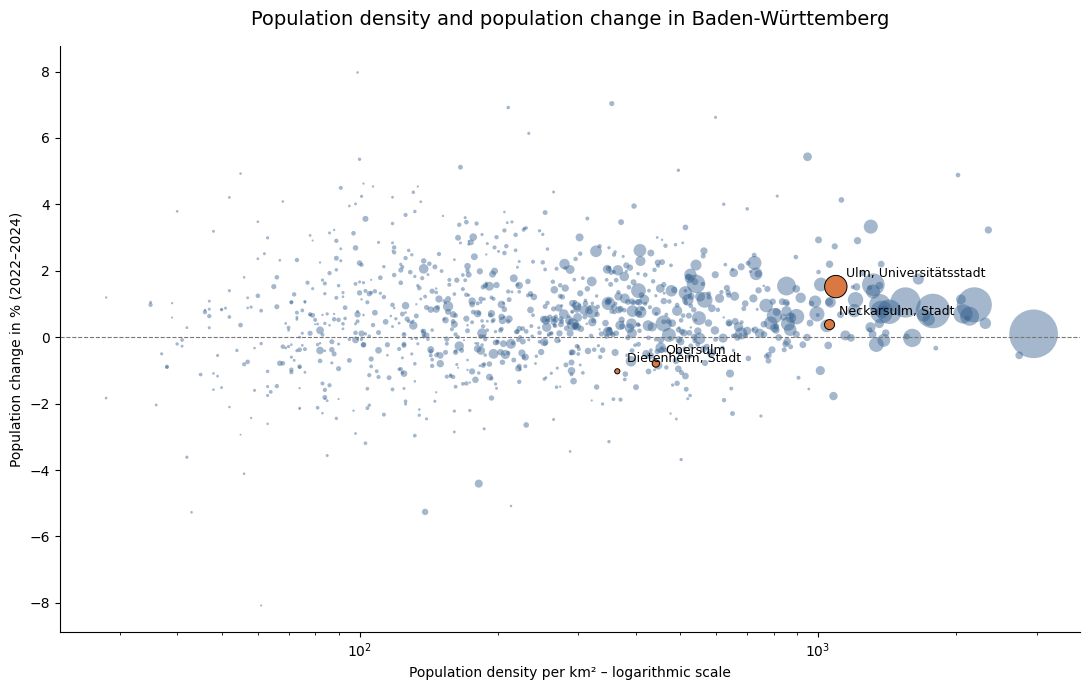

In [37]:
municipality_profile = latest[
    [
        "municipality_code",
        "municipality",
        "population",
        "population_density"
    ]
].merge(
    population_change[
        [
            "municipality_code",
            "population_change",
            "population_change_pct"
        ]
    ],
    on="municipality_code",
    how="left"
)

profile_filtered = municipality_profile[
    municipality_profile["population"] >= 1000
].copy()

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    profile_filtered["population_density"],
    profile_filtered["population_change_pct"],
    s=profile_filtered["population"] / 500,
    alpha=0.45,
    color="#35618f",
    edgecolor="none"
)

ax.axhline(0, color="#777777", linewidth=0.8, linestyle="--")
ax.set_xscale("log")

local_municipalities = profile_filtered[
    profile_filtered["municipality"].str.contains(
        "Ulm|Dietenheim",
        case=False,
        na=False
    )
]

ax.scatter(
    local_municipalities["population_density"],
    local_municipalities["population_change_pct"],
    s=local_municipalities["population"] / 500,
    color="#d97841",
    edgecolor="black",
    linewidth=0.7
)

for _, row in local_municipalities.iterrows():
    ax.annotate(
        row["municipality"],
        (
            row["population_density"],
            row["population_change_pct"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Population density and population change in Baden-Württemberg",
    fontsize=14,
    pad=15
)
ax.set_xlabel("Population density per km² – logarithmic scale")
ax.set_ylabel(
    f"Population change in % ({str(first_date)[:4]}–{str(last_date)[:4]})"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "visuals/population_density_and_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

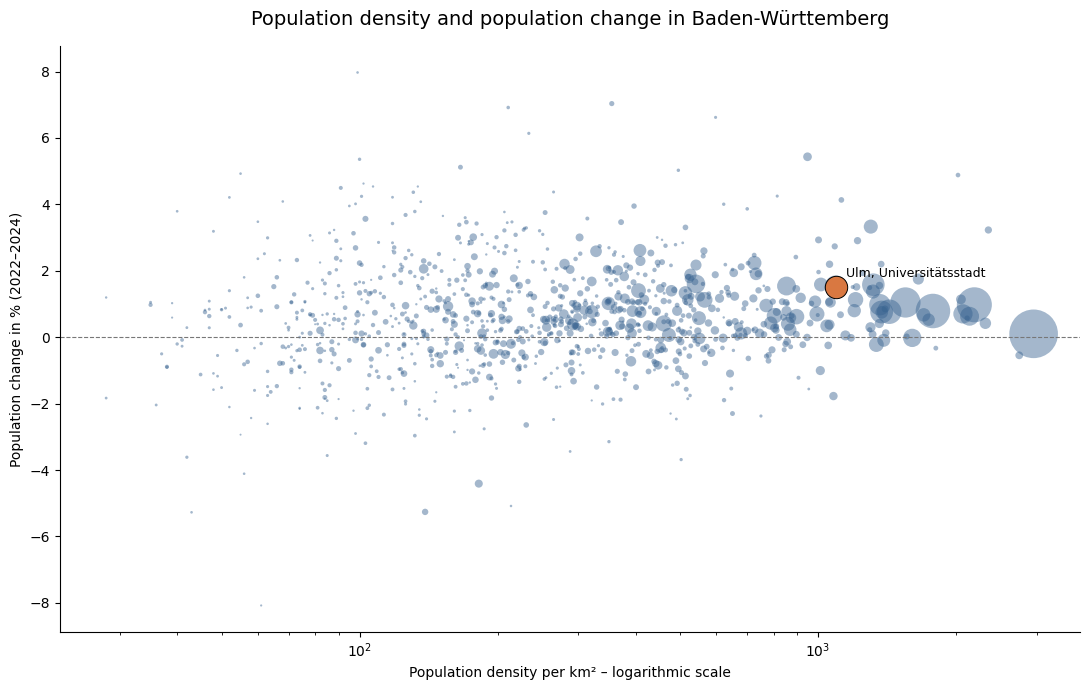

In [39]:
municipality_profile = latest[
    [
        "municipality_code",
        "municipality",
        "population",
        "population_density"
    ]
].merge(
    population_change[
        [
            "municipality_code",
            "population_change",
            "population_change_pct"
        ]
    ],
    on="municipality_code",
    how="left"
)

profile_filtered = municipality_profile[
    municipality_profile["population"] >= 1000
].copy()

fig, ax = plt.subplots(figsize=(11, 7))

# All municipalities
ax.scatter(
    profile_filtered["population_density"],
    profile_filtered["population_change_pct"],
    s=profile_filtered["population"] / 500,
    alpha=0.45,
    color="#35618f",
    edgecolor="none"
)

# Line separating population growth from decline
ax.axhline(
    0,
    color="#777777",
    linewidth=0.8,
    linestyle="--"
)

ax.set_xscale("log")

# Highlight only Ulm
ulm = profile_filtered[
    profile_filtered["municipality"].eq(
        "Ulm, Universitätsstadt"
    )
]

ax.scatter(
    ulm["population_density"],
    ulm["population_change_pct"],
    s=ulm["population"] / 500,
    color="#d97841",
    edgecolor="black",
    linewidth=0.7
)

# Add label for Ulm
for _, row in ulm.iterrows():
    ax.annotate(
        row["municipality"],
        (
            row["population_density"],
            row["population_change_pct"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Population density and population change in Baden-Württemberg",
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "Population density per km² – logarithmic scale"
)

ax.set_ylabel(
    f"Population change in % "
    f"({str(first_date)[:4]}–{str(last_date)[:4]})"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "visuals/population_density_and_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
total_population_first = population_change[first_date].sum()
total_population_last = population_change[last_date].sum()

total_population_change = (
    total_population_last - total_population_first
)

total_population_change_pct = (
    total_population_change
    / total_population_first
    * 100
)

growing_municipalities = (
    population_change["population_change"] > 0
).sum()

declining_municipalities = (
    population_change["population_change"] < 0
).sum()

unchanged_municipalities = (
    population_change["population_change"] == 0
).sum()

state_summary = pd.DataFrame(
    {
        "Metric": [
            f"Total population in {str(first_date)[:4]}",
            f"Total population in {str(last_date)[:4]}",
            "Absolute population change",
            "Population change in %",
            "Municipalities with population growth",
            "Municipalities with population decline",
            "Municipalities without change"
        ],
        "Value": [
            f"{int(total_population_first):,}".replace(",", "."),
            f"{int(total_population_last):,}".replace(",", "."),
            f"{int(total_population_change):+,}".replace(",", "."),
            f"{total_population_change_pct:+.2f}%",
            int(growing_municipalities),
            int(declining_municipalities),
            int(unchanged_municipalities)
        ]
    }
)

ulm_summary = population_change[
    population_change["municipality"].eq(
        "Ulm, Universitätsstadt"
    )
][
    [
        "municipality",
        first_date,
        last_date,
        "population_change",
        "population_change_pct"
    ]
].copy()

display(state_summary)
display(ulm_summary)

,Metric,Value
0,Total population in 2022,11.167.721
1,Total population in 2024,11.245.898
2,Absolute population change,+78.177
3,Population change in %,+0.70%
4,Municipalities with population growth,729
5,Municipalities with population decline,368
6,Municipalities without change,4


date,municipality,2022-12-31,2024-12-31,population_change,population_change_pct
913,"Ulm, Universitätsstadt",127932,129882,1950,1.524247


## Key findings

- The population of Baden-Württemberg increased from **11,167,721 in 2022** to **11,245,898 in 2024**. This represents an increase of **78,177 residents**, or **0.70%**.
- Population growth was recorded in **729 of 1,101 municipalities (66.2%)**, while **368 municipalities (33.4%)** experienced a decline. Four municipalities recorded no change.
- The largest absolute population increases were concentrated mainly in larger urban municipalities. At the same time, population decline affected municipalities of different sizes, demonstrating that the overall state-level growth was not distributed evenly.
- Ulm grew from **127,932 to 129,882 residents**, an increase of **1,950 residents or 1.52%**. Its growth rate was therefore more than twice the overall rate for Baden-Württemberg.
- Ulm’s comparatively strong population growth may increase demand for housing, transport, public services and urban infrastructure. Additional demographic and spatial data would be required to determine the specific planning implications.

## Analytical limitations

- The analysis compares municipal population figures for 2022 and 2024 and does not explain the causes of population change.
- Percentage changes can appear disproportionately large in municipalities with small populations. Absolute and relative values should therefore be interpreted together.
- Further analysis should include age structure, migration, housing, employment and infrastructure data.
  

In [41]:
from pathlib import Path

processed_data_directory = Path("data/processed")
processed_data_directory.mkdir(
    parents=True,
    exist_ok=True
)

analysis.to_csv(
    processed_data_directory / "municipal_population_analysis.csv",
    index=False,
    encoding="utf-8"
)

print(
    "Processed dataset saved:",
    processed_data_directory / "municipal_population_analysis.csv"
)

Processed dataset saved: data/processed/municipal_population_analysis.csv
